In [4]:
!pip install opencv-python matplotlib scikit-learn

In [2]:
import kagglehub

path = kagglehub.dataset_download("jocelyndumlao/seaclear-marine-debris-detection-and-segmentation")

print(path)

100%|██████████| 1.61G/1.61G [00:43<00:00, 40.0MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/jocelyndumlao/seaclear-marine-debris-detection-and-segmentation/versions/1


In [3]:
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

json_path = "/root/.cache/kagglehub/datasets/jocelyndumlao/seaclear-marine-debris-detection-and-segmentation/versions/1/Seaclear Marine Debris Dataset/dataset.json"
base_path = os.path.dirname(json_path)

with open(json_path) as f:
    data = json.load(f)

images = data["images"]
annotations = data["annotations"]

In [5]:
ann_map = {}

for ann in annotations:
    ann_map.setdefault(ann["image_id"], []).append(ann["bbox"])

In [6]:
image_paths = {}

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".jpg"):
            image_paths[file] = os.path.join(root, file)

print("Total gambar ditemukan:", len(image_paths))

Total gambar ditemukan: 8610


In [7]:
def detect_edges_bbox(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur, 30, 100)  # lebih sensitif

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for cnt in contours:
        x,y,w,h = cv2.boundingRect(cnt)
        if w*h > 200:  # filter noise
            boxes.append([x,y,w,h])

    return edges, boxes

In [8]:
def compute_iou(box1, box2):
    x1,y1,w1,h1 = box1
    x2,y2,w2,h2 = box2

    xa = max(x1, x2)
    ya = max(y1, y2)
    xb = min(x1+w1, x2+w2)
    yb = min(y1+h1, y2+h2)

    inter = max(0, xb-xa) * max(0, yb-ya)
    union = w1*h1 + w2*h2 - inter

    if union == 0:
        return 0
    return inter/union

In [9]:
ious = []

for img_info in images[:200]:  # ambil sebagian dulu
    file_name = img_info["file_name"]

    if file_name not in image_paths:
        continue

    img = cv2.imread(image_paths[file_name])

    if img is None:
        continue

    edges, pred_boxes = detect_edges_bbox(img)
    gt_boxes = ann_map.get(img_info["id"], [])

    for gt in gt_boxes:
        best_iou = 0
        for pb in pred_boxes:
            iou = compute_iou(pb, gt)
            best_iou = max(best_iou, iou)

        ious.append(best_iou)

if len(ious) == 0:
    print("IoU kosong")
else:
    mean_iou = np.mean(ious)
    percent = mean_iou * 100

    print("Rata-rata IoU Edge Detection:", mean_iou)
    print("Persentase Akurasi (IoU): {:.2f}%".format(percent))

Rata-rata IoU Edge Detection: 0.012517575630064141
Persentase Akurasi (IoU): 1.25%


In [10]:
high = sum(i > 0.5 for i in ious)
medium = sum(0.2 < i <= 0.5 for i in ious)
low = sum(i <= 0.2 for i in ious)

total = len(ious)

print("Distribusi Akurasi:")
print("IoU > 0.5  (bagus):", high)
print("0.2 < IoU ≤ 0.5 (cukup):", medium)
print("IoU ≤ 0.2 (rendah):", low)

Distribusi Akurasi:
IoU > 0.5  (bagus): 2
0.2 < IoU ≤ 0.5 (cukup): 23
IoU ≤ 0.2 (rendah): 1120


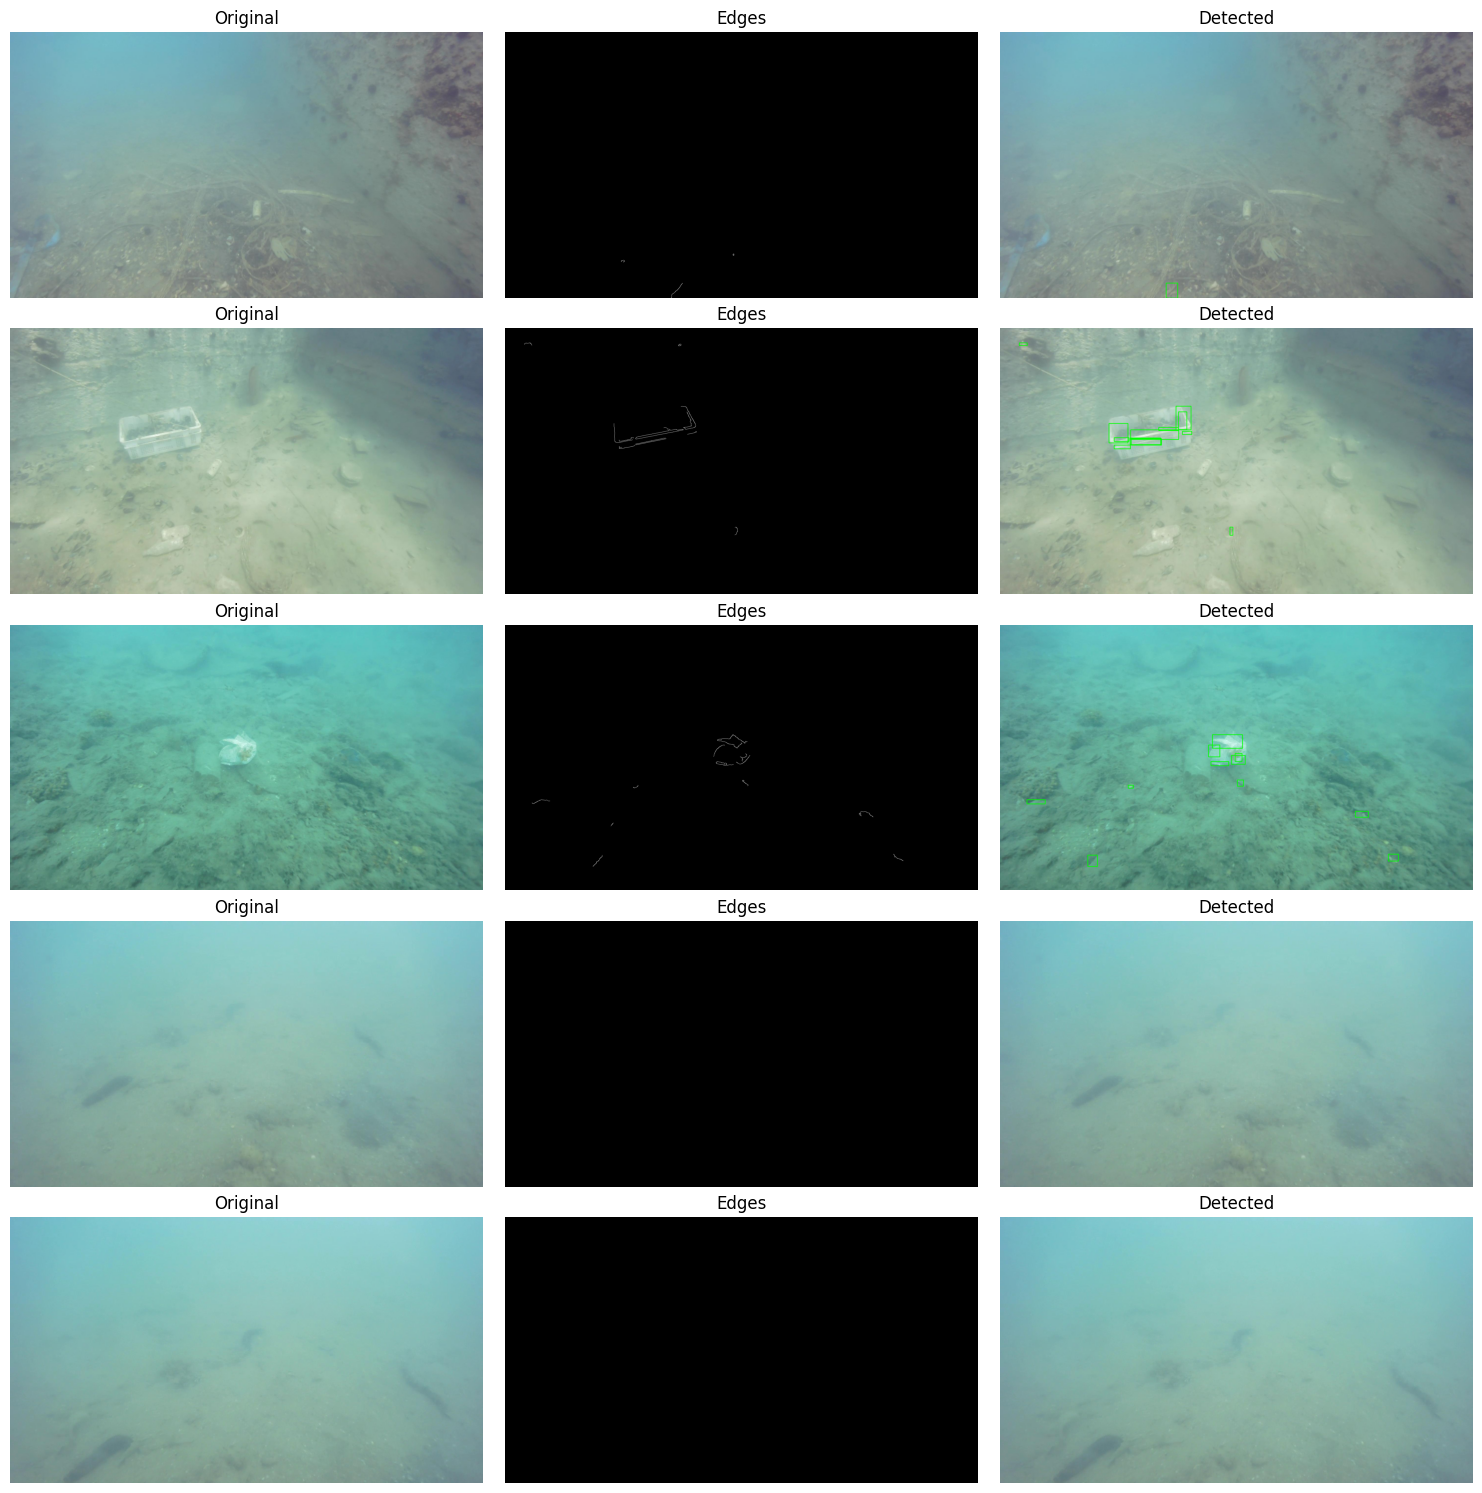

In [11]:
num_images = 5  # jumlah gambar yang mau ditampilkan

plt.figure(figsize=(15, num_images*3))

for i in range(num_images):
    img_info = images[i]
    file_name = img_info["file_name"]

    if file_name not in image_paths:
        continue

    img = cv2.imread(image_paths[file_name])
    edges, boxes = detect_edges_bbox(img)

    # gambar untuk box (biar tidak ngerusak original)
    img_box = img.copy()

    for (x,y,w,h) in boxes:
        cv2.rectangle(img_box, (x,y), (x+w,y+h), (0,255,0), 2)

    # tampilkan
    plt.subplot(num_images, 3, i*3 + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(num_images, 3, i*3 + 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges")
    plt.axis('off')

    plt.subplot(num_images, 3, i*3 + 3)
    plt.imshow(cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB))
    plt.title("Detected")
    plt.axis('off')

plt.tight_layout()
plt.show()

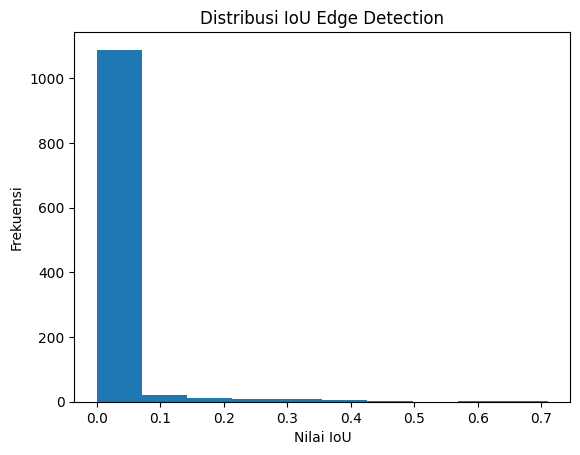

In [12]:
plt.figure()
plt.hist(ious)
plt.title("Distribusi IoU Edge Detection")
plt.xlabel("Nilai IoU")
plt.ylabel("Frekuensi")

plt.show()

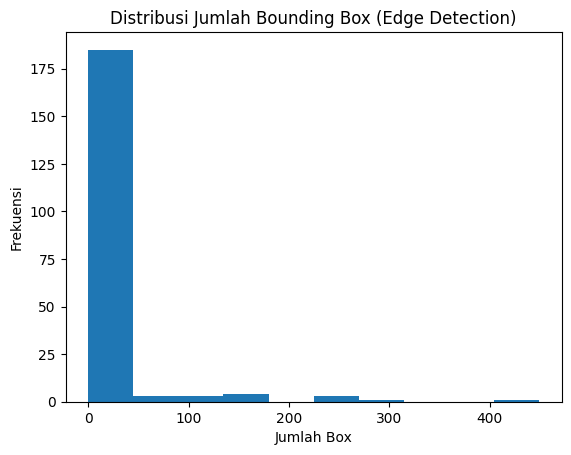

In [13]:
num_boxes = []

for img_info in images[:200]:
    file_name = img_info["file_name"]

    if file_name not in image_paths:
        continue

    img = cv2.imread(image_paths[file_name])
    _, boxes = detect_edges_bbox(img)

    num_boxes.append(len(boxes))

plt.figure()
plt.hist(num_boxes)
plt.title("Distribusi Jumlah Bounding Box (Edge Detection)")
plt.xlabel("Jumlah Box")
plt.ylabel("Frekuensi")

plt.show()